# Dubins car latent preference-aligned safety filter (ground-truth margin)

**What this does:** Trains a DreamerV3 world model on the Dubins sidewalk scenario, learns a preference-aligned failure margin l(x) in latent space from ground-truth pairwise labels, then trains and visualizes a latent safety filter.

**What it shows:** The preference-aligned safety filter transfers from privileged state to a world models's latent space.

**Source code:** `dubins/`.

## Preference-aligned latent safety filter

This notebook transfers the entire pipeline from privileged state into latent space.
1. **World model:** a frozen DreamerV3 transition-only world model encodes each observation into a 544-d latent `z` (the space the filter will operate in).
2. **Failure margin:** a margin head `l(z)` is trained from ground-truth pairwise labels with a Bradley-Terry loss. We use the raw BT margin as `l(z)`.
3. **Latent DDQN:** a reach-avoid value function is trained on `l(z)`, exactly as in notebook 01 but uses latent features instead of privileged states.
4. **Safety filter:** filters a nominal policy with learned value function.

*Data generation:* `generate_pref_labels_dubins_sidewalk.py`

*World model:* pretrained transition-only DreamerV3.

Set `PROFILE` to switch between two preference sets (`set_a`, `set_b`).

In [ ]:
import sys; sys.path.insert(0, "dubins")
import sys, os, pickle, argparse, copy, collections, pathlib, subprocess
sys.path.insert(0, "dubins/dreamerv3")
import numpy as np, torch, gym
import ruamel.yaml as yaml, tools, models
device = torch.device("cuda")
cfg = yaml.YAML(typ="safe", pure=True).load(open("dubins/configs.yaml").read())["defaults"]
config = argparse.Namespace(**{k: tools.args_type(v)(v) for k, v in cfg.items()})
config.num_actions = 3; config.device = device; config.use_margin_head = False
sz = config.size[0]
obs_space = gym.spaces.Dict({"obs_state": gym.spaces.Box(-1,1,(2,),np.float32),
                             "image": gym.spaces.Box(0,255,(sz,sz,3),np.uint8)})
print("config loaded | image size", sz)

### Generate world model training data

Renders Dubins rollouts (image + state + privileged state) to `data/wm_training_data.pkl` (world model training data). Skipped when the file already exists.

In [ ]:
if not os.path.exists("data/wm_training_data.pkl"):
    print("generating data/wm_training_data.pkl ...", flush=True)
    subprocess.run([sys.executable, "dubins/generate_data_dubins_sidewalk.py",
                    "--out", "data/wm_training_data.pkl"], check=True)
    print("done -> data/wm_training_data.pkl")
else:
    print("using existing data/wm_training_data.pkl  (set GEN_DATA=True to regenerate)")

### Pretrain (or load) the world model

The latent safety filter runs on a frozen DreamerV3 world model. This cell either pretrains it (encoder + RSSM dynamics + decoder) on `data/wm_training_data.pkl` (`dreamer_offline_sidewalk.pretrain_model_only`), or loads a saved checkpoint. Set `TRAIN_WM=True` to pretrain (saved to `checkpoints/dubins/wm_transition_only.pt`).

In [ ]:
TRAIN_WM = False                                    # True: pretrain the WM (GPU, ~hours)
WM_CKPT  = "checkpoints/dubins/wm_transition_only.pt"
WM_STEPS = config.pretrain_steps                     # 50000 (100000 in paper)

if TRAIN_WM:
    os.environ["WANDB_MODE"] = "disabled"            # the trainer's Logger uses wandb; run offline
    import dreamer_offline_sidewalk as dofs
    from tqdm import trange
    tcfg = copy.copy(config); tcfg.compile = False; tcfg.from_ckpt = None; tcfg.pretrain_steps = WM_STEPS
    tcfg.logdir = "logs/wm_pretrain_nb"; pathlib.Path(tcfg.logdir).mkdir(parents=True, exist_ok=True)
    tcfg.traindir = pathlib.Path(tcfg.logdir) / "train_eps"; tcfg.evaldir = pathlib.Path(tcfg.logdir) / "eval_eps"
    tcfg.traindir.mkdir(parents=True, exist_ok=True); tcfg.evaldir.mkdir(parents=True, exist_ok=True)
    obs_full = gym.spaces.Dict({
        "state": gym.spaces.Box(np.float32([tcfg.x_min, tcfg.y_min, 0.0]), np.float32([tcfg.x_max, tcfg.y_max, 2*np.pi])),
        "obs_state": gym.spaces.Box(-1, 1, (2,), np.float32),
        "image": gym.spaces.Box(0, 255, (sz, sz, 3), np.uint8)})
    logger = tools.Logger(pathlib.Path(tcfg.logdir), 0)
    eps = collections.OrderedDict(); tools.fill_expert_dataset_dubins(tcfg, eps)      # loads the training data
    dset = dofs.make_dataset(eps, tcfg)
    agent = dofs.Dreamer(obs_full, gym.spaces.Discrete(3), tcfg, logger).to(device)
    agent.requires_grad_(False); agent._pref_weights = dofs.PREF_PROFILES["set_a"]
    print(f"pretraining world model (encoder + dynamics + decoder) for {WM_STEPS} steps ...", flush=True)
    for step in trange(WM_STEPS, ncols=0):
        agent.pretrain_model_only(next(dset), step)
    torch.save({"agent_state_dict": agent.state_dict()}, WM_CKPT)
    print("saved trained world model ->", WM_CKPT)
    sd = {k[4:] if k.startswith("_wm.") else k: v for k, v in agent.state_dict().items() if k.startswith("_wm.")}
    wm = models.WorldModel(obs_space, gym.spaces.Discrete(3), 0, config).to(device)
    wm.load_state_dict(sd, strict=True)
else:
    wm = models.WorldModel(obs_space, gym.spaces.Discrete(3), 0, config).to(device)
    ck = torch.load(WM_CKPT, map_location=device)
    sd = {k[len("_wm._orig_mod."):] if k.startswith("_wm._orig_mod.") else k[4:] if k.startswith("_wm.") else k: v
          for k, v in ck["agent_state_dict"].items() if "_wm" in k}
    wm.load_state_dict(sd, strict=True)
print("world model ready:", "trained" if TRAIN_WM else f"loaded from {WM_CKPT}")

*Train the failure margin*

Trains the failure margin on frozen world model features and the generated training data.

In [ ]:
wm.eval(); wm.dynamics.sample = False
for p in wm.parameters(): p.requires_grad_(False)

# preference labels + one-time latent encoding of the pool through the frozen WM
data  = pickle.load(open("data/pref_labels_set_a.pkl", "rb"))
g     = torch.tensor(data["margin"], dtype=torch.float32, device=device)
pairs = torch.tensor(data["pairs"],  dtype=torch.long,    device=device)
label = torch.tensor(data["label"],  dtype=torch.float32, device=device)
cat   = data["category"]

@torch.no_grad()
def encode_pool(imgs, obs, chunk=256):
    out = []
    for k in range(0, len(imgs), chunk):
        im = imgs[k:k+chunk].astype(np.float32); ob = obs[k:k+chunk].astype(np.float32); B = len(im)
        a = np.zeros((B,1,3), np.float32); a[:,:,1] = 1.0
        d = {"image": im[:,None], "obs_state": ob[:,None], "action": a,
             "is_first": np.ones((B,1),np.float32), "is_terminal": np.zeros((B,1),np.float32)}
        d = wm.preprocess(d); emb = wm.encoder(d)
        post, _ = wm.dynamics.observe(emb, d["action"], d["is_first"])
        out.append(wm.dynamics.get_feat(post)[:,0])
    return torch.cat(out, 0)

feats = encode_pool(data["imgs"], data["obs_state"])
print("latent features:", tuple(feats.shape))

In [2]:
import torch.nn as nn
from torch.nn.utils import spectral_norm

class MarginHead(nn.Module):
    def __init__(self, feat_size, units=512, layers=2, lipschitz=True):
        super().__init__()
        sn = spectral_norm if lipschitz else (lambda m: m)
        d, mods = feat_size, []
        for _ in range(layers):
            mods += [sn(nn.Linear(d, units)), nn.SiLU()]
            d = units
        self.body = nn.Sequential(*mods)
        self.out = sn(nn.Linear(d, 1))
    def forward(self, feat): return self.out(self.body(feat)).squeeze(-1)

def pred_reward(model, feat):
    return model(feat)

# Bradley-Terry loss function
def pref_loss(pred, target):
    """
    pred (B, 2): Predicted scores for each item in the pair.
    target (B, ): Ground truth labels indicating which item is preferred (0 or 1).
    """
    log_prob = torch.log_softmax(pred, dim=1)
    mu = torch.stack([target, 1.0 - target], dim=1)
    loss = -(mu * log_prob).sum(dim=1).mean()
    
    return loss

In [ ]:
# failure margin visualization
# defines build_margin_grid + plot_margin + visualize_margin.
# used both during training (train_margin calls plot_margin each eval) and
# standalone afterwards (call visualize_margin with the returned grid).
import os, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import generate_data_dubins_sidewalk as gen
from generate_pref_labels_dubins_sidewalk import weighted_margin_np


def build_margin_grid(wm, weights, ng=41, nz=4, dom=1.5):
    """Render an (ng x ng) grid of (x,y) at nz headings, encode once through the
    frozen WM, and precompute the ground-truth margin. Reused across evals."""
    R, SW = gen.OBS_R, gen.SIDEWALK_Y
    emoji = gen.load_tree_emoji(); sz = wm._config.size[0]
    xs = np.linspace(-dom, dom, ng); ys = np.linspace(-dom, dom, ng)
    thetas = np.linspace(0, 2 * np.pi, nz, endpoint=False)
    imgs, obs, idxs, gt = [], [], [], np.zeros((ng, ng))
    for i0, x in enumerate(xs):
        for i1, y in enumerate(ys):
            gt[i0, i1] = weighted_margin_np(x, y, weights, R, SW)
            for i2, th in enumerate(thetas):
                imgs.append(gen.render_state(np.array([x, y, th], np.float32), 1.0, 0.05, emoji, sz))
                obs.append([np.cos(th), np.sin(th)]); idxs.append((i0, i1, i2))
    feats = encode_pool(np.array(imgs, np.uint8), np.array(obs, np.float32))
    return dict(feats=feats, gt=gt, idxs=np.array(idxs), ng=ng, nz=nz, extent=[-dom, dom, -dom, dom])


def plot_margin(model, grid, save_path):
    """Plot the RAW learned margin (mean over headings), the ground-truth margin,
    and sign agreement."""
    R, SW = gen.OBS_R, gen.SIDEWALK_Y
    with torch.no_grad():
        pf = pred_reward(model, grid["feats"]).cpu().numpy()
    ng, nz = grid["ng"], grid["nz"]
    cube = np.zeros((ng, ng, nz))
    for k, (i0, i1, i2) in enumerate(grid["idxs"]): cube[i0, i1, i2] = pf[k]
    pred = cube.mean(axis=2)                       # RAW learned margin
    gt = grid["gt"]
    sign_err = float((np.sign(pred.ravel()) != np.sign(gt.ravel())).mean())

    ext = grid["extent"]
    pvmax = max(np.abs(pred).max(), 1e-3)          # learned has its own (raw) scale
    gvmax = max(np.abs(gt).max(), 1e-3)
    def _ov(ax):
        ax.add_patch(plt.Circle((0, 0), R, fill=False, color="k", lw=1.5))
        ax.axhline(SW, color="k", ls="--", lw=1); ax.axhline(-SW, color="k", ls="--", lw=1)
        ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    panels = [(axes[0], pred.T, f"learned margin (raw)  [{pred.min():+.1f}, {pred.max():+.1f}]", pvmax),
              (axes[1], gt.T,   "ground-truth margin", gvmax)]
    for ax, field, title, vm in panels:
        im = ax.imshow(field, extent=ext, origin="lower", cmap="seismic",
                       vmin=-vm, vmax=vm, interpolation="none")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); ax.set_title(title); _ov(ax)
    axes[2].imshow(np.sign(pred.T) == np.sign(gt.T), extent=ext, origin="lower",
                   cmap="RdYlGn", vmin=0, vmax=1, interpolation="none")
    axes[2].set_title("sign(pred)==sign(gt)  (raw zero)"); _ov(axes[2])
    fig.suptitle(f"raw sign-error={sign_err*100:.1f}%", fontsize=13)
    fig.tight_layout(); fig.savefig(save_path, dpi=110); plt.close(fig)
    return sign_err


def visualize_margin(model, save_path, grid=None, wm=None, weights=None, grid_res=41):
    """Convenience wrapper. Reuses `grid` if given (fast); otherwise builds it from
    `wm` + `weights`. Returns (sign_err, grid) so the grid can be cached and reused."""
    if grid is None:
        assert wm is not None and weights is not None, "pass wm + weights to build the grid"
        grid = build_margin_grid(wm, weights, ng=grid_res)
    return plot_margin(model, grid, save_path), grid


In [4]:
# eval: pairwise ranking accuracy (overall + per ss/ff/fs), corr(r,g), + raw margin plot
def evaluate(model, feats, pairs, label, g, cat, va, is_val, grid=None, plot_path=None):
    with torch.no_grad():
        R1 = pred_reward(model, feats[pairs[va, 0]]); R2 = pred_reward(model, feats[pairs[va, 1]])
        correct = (R1 > R2) == (label[va] > 0.5); cats = cat[va.cpu().numpy()]
        m = {"acc": correct.float().mean().item()}
        for c in ("ss", "ff", "fs"):
            sel = torch.tensor(cats == c, device=feats.device)
            m[c] = correct[sel].float().mean().item() if sel.any() else float("nan")
        r = pred_reward(model, feats[is_val]); gv = g[is_val]; rz, gz = r - r.mean(), gv - gv.mean()
        m["corr"] = (rz * gz).sum().item() / (rz.norm().item() * gz.norm().item() + 1e-8)
    if grid is not None and plot_path is not None:
        m["sign_err"] = plot_margin(model, grid, plot_path)
    return m


# training loop for the preference margin head. returns (model, grid); grid is the
# eval grid (or None) so it can be reused by visualize_margin after training.
def train_margin(feats, pairs, label, g, cat, config, steps=5000, eval_interval=500,
                 lr=1e-3, batch_size=1024, lipschitz=True, val_frac=0.2, seed=0,
                 save_path=None, wm=None, weights=None, log_dir=None, grid_res=41):
    device = feats.device
    model = MarginHead(feats.shape[1], config.units, layers=2, lipschitz=lipschitz).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    rng = np.random.default_rng(seed); M = len(g)
    is_val = torch.zeros(M, dtype=torch.bool, device=device)
    is_val[rng.choice(M, int(val_frac * M), replace=False)] = True
    tr = torch.where((~is_val[pairs[:, 0]]) & (~is_val[pairs[:, 1]]))[0]
    va = torch.where(( is_val[pairs[:, 0]]) & ( is_val[pairs[:, 1]]))[0]

    grid = None
    if log_dir is not None and wm is not None and weights is not None:
        os.makedirs(log_dir, exist_ok=True)
        print("building margin eval grid (once) ..."); grid = build_margin_grid(wm, weights, ng=grid_res)

    for step in range(1, steps + 1):
        batch = tr[torch.randint(len(tr), (batch_size,), device=device)]
        pred = torch.stack([pred_reward(model, feats[pairs[batch, 0]]),
                            pred_reward(model, feats[pairs[batch, 1]])], dim=1)
        loss = pref_loss(pred, label[batch])
        opt.zero_grad(); loss.backward(); opt.step()
        if step % eval_interval == 0 or step == steps:
            pp = f"{log_dir}/margin_{step:05d}.png" if grid is not None else None
            e = evaluate(model, feats, pairs, label, g, cat, va, is_val, grid=grid, plot_path=pp)
            se = f" sign_err={e['sign_err']*100:.1f}%" if "sign_err" in e else ""
            print(f"[{step:5d}] loss={loss.item():.3f} acc={e['acc']:.3f} "
                  f"(ss={e['ss']:.2f} ff={e['ff']:.2f} fs={e['fs']:.2f}) corr(r,g)={e['corr']:.3f}{se}")
    if save_path:
        torch.save(model.state_dict(), save_path); print(f"saved margin head -> {save_path}")
    return model, grid


In [5]:
# train the preference margin head (raw margin plots saved to log_dir each eval_interval)
model, grid = train_margin(feats, pairs, label, g, cat, config,
                     steps=5000, eval_interval=500, lr=1e-3, batch_size=1024, lipschitz=True,
                     wm=wm, weights=data["weights"], log_dir="logs/pref_margin_train",
                     save_path="checkpoints/dubins/pref_margin_head_set_a.pt")


building margin eval grid (once) ...


[  500] loss=0.168 acc=0.935 (ss=0.88 ff=0.92 fs=1.00) corr(r,g)=0.922 sign_err=32.7%


[ 1000] loss=0.147 acc=0.944 (ss=0.91 ff=0.92 fs=1.00) corr(r,g)=0.926 sign_err=22.2%


[ 1500] loss=0.151 acc=0.941 (ss=0.89 ff=0.93 fs=1.00) corr(r,g)=0.921 sign_err=21.4%


[ 2000] loss=0.154 acc=0.951 (ss=0.91 ff=0.94 fs=1.00) corr(r,g)=0.925 sign_err=17.9%


...

[ 3000] loss=0.141 acc=0.951 (ss=0.92 ff=0.93 fs=1.00) corr(r,g)=0.925 sign_err=20.5%


[ 3500] loss=0.146 acc=0.949 (ss=0.91 ff=0.94 fs=1.00) corr(r,g)=0.925 sign_err=19.4%


[ 4000] loss=0.136 acc=0.946 (ss=0.90 ff=0.93 fs=1.00) corr(r,g)=0.923 sign_err=18.7%


[ 4500] loss=0.134 acc=0.948 (ss=0.91 ff=0.94 fs=0.99) corr(r,g)=0.921 sign_err=18.5%


[ 5000] loss=0.122 acc=0.946 (ss=0.90 ff=0.94 fs=1.00) corr(r,g)=0.925 sign_err=18.3%
saved margin head -> checkpoints/dubins/pref_margin_head_set_a.pt


In [ ]:
# visualize the raw learned failure margin after training.
# reuses the eval grid from train_margin (grid=grid)
model = MarginHead(feats.shape[1], config.units, layers=2, lipschitz=True).to(device)
model.load_state_dict(torch.load("checkpoints/dubins/pref_margin_head_set_a.pt", map_location=device))

sign_err, grid = visualize_margin(model, "logs/pref_margin_train/margin_after_training.png",
                                  grid=grid, wm=wm, weights=data["weights"])
print(f"raw sign-error = {sign_err*100:.1f}%  -> logs/pref_margin_train/margin_after_training.png")


raw sign-error = 18.5%  -> logs/pref_margin_train/margin_after_training.png


The learned Set-A failure margin. Held-out margin accuracy ≈0.95, sign-error ≈16–22%.

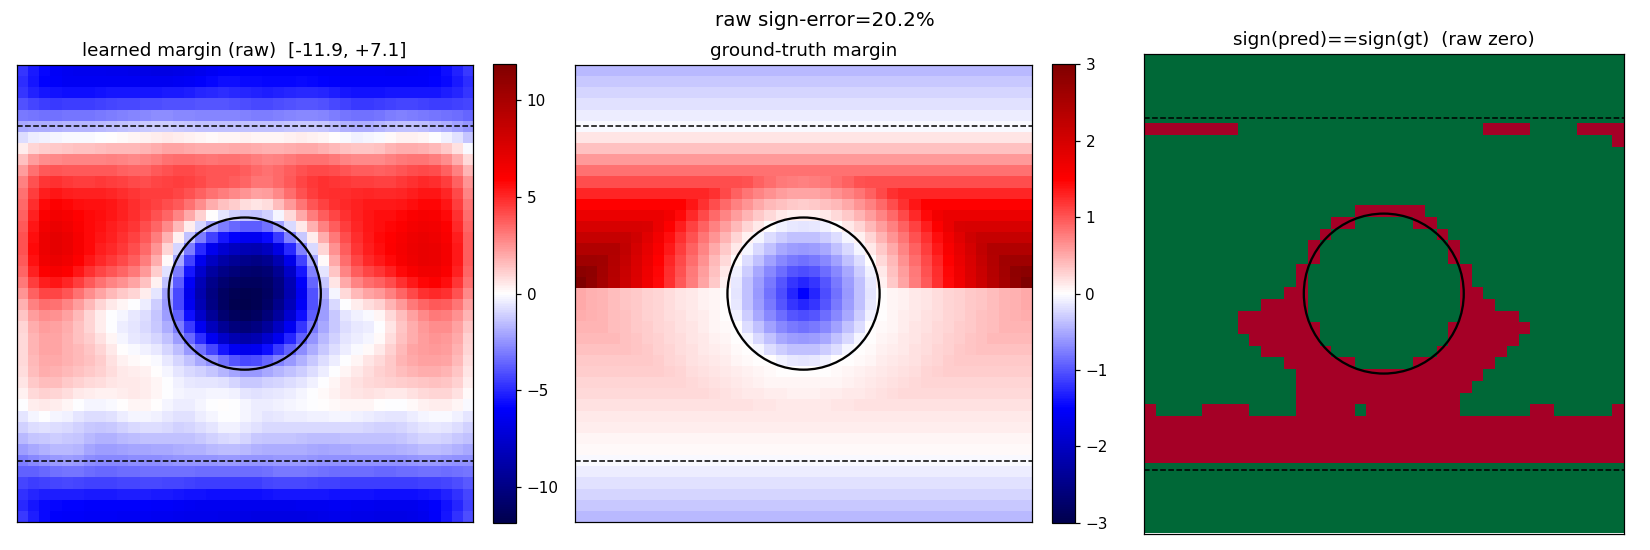

## Latent safety filter

The filter logic is copied exactly from the privileged filter in notebook 01, but in the latent space, using the raw preference `MarginHead` as `l(x)`, and the DDQN value function trained on it. Set `PROFILE` to `set_a` / `set_b`.

In [ ]:
# safety filter setup
import sys, pathlib, os, glob
import numpy as np, torch, gym
import ruamel.yaml as yaml
from torch import nn
from torch.nn.utils import spectral_norm
os.environ["MUJOCO_GL"] = "osmesa"
sys.path.insert(0, "dubins/safety_rl")
wm_root = pathlib.Path('dubins/dreamerv3').resolve()
for p in (str(wm_root), str(wm_root.parent)):
    if p not in sys.path: sys.path.insert(0, p)
import sys as _sys; _sys.path.insert(0, "dubins/safety_rl")
from gym_reachability import gym_reachability
from RARL.model import Model
import tools, models

def recursive_update(base, update):
    for k, v in update.items():
        if isinstance(v, dict) and k in base: recursive_update(base[k], v)
        else: base[k] = v
_cfg = yaml.YAML(typ='safe', pure=True).load(pathlib.Path('dubins/configs.yaml').resolve().read_text())
defaults = {}; recursive_update(defaults, _cfg['defaults'])
class Config: pass
config = Config()
for k, v in defaults.items(): setattr(config, k, v)
config.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
config.num_actions = 3
config.use_margin_head = False                       # transition-only WM

# choose preference profile
PROFILE = 'set_b'                                     # 'set_a' or 'set_b'
_CKPTS = {
  'set_a': dict(lx='checkpoints/dubins/pref_margin_head_set_a.pt',
                q_dir='logs/experiments_pref/car-DDQN/pref_seta-toEnd/model'),
  'set_b': dict(lx='checkpoints/dubins/pref_margin_head_set_b.pt',
                q_dir='logs/experiments_pref/car-DDQN/pref_setb-toEnd/model'),
}
print("Profile:", PROFILE)

bounds = np.array([[config.x_min, config.x_max], [config.y_min, config.y_max], [0, 2*np.pi]])
low, high = bounds[:, 0], bounds[:, 1]; midpoint, interval = (low+high)/2, high-low
image_size = config.size[0]
observation_space = gym.spaces.Dict({
    'state': gym.spaces.Box(np.float32(midpoint-interval/2), np.float32(midpoint+interval/2)),
    'obs_state': gym.spaces.Box(-1, 1, (2,), np.float32),
    'image': gym.spaces.Box(0, 255, (image_size, image_size, 3), np.uint8)})
action_space = gym.spaces.Discrete(3)

# world model (transition-only, no margin head)
wm = models.WorldModel(observation_space, action_space, 0, config).to(config.device)
_wmck = torch.load("checkpoints/dubins/wm_transition_only.pt", map_location=config.device)
_pfx = '_wm._orig_mod.'
_wmsd = {k[len(_pfx):] if k.startswith(_pfx) else k: v for k, v in _wmck['agent_state_dict'].items() if '_wm' in k}
wm.load_state_dict(_wmsd, strict=True); wm.eval(); wm.dynamics.sample = False
print("Loaded WM: checkpoints/dubins/wm_transition_only.pt")

# raw preference margin head = l(x)
class MarginHead(nn.Module):
    def __init__(self, feat_size, units=512, layers=2, lipschitz=True):
        super().__init__()
        sn = spectral_norm if lipschitz else (lambda m: m)
        d, mods = feat_size, []
        for _ in range(layers): mods += [sn(nn.Linear(d, units)), nn.SiLU()]; d = units
        self.body = nn.Sequential(*mods); self.out = sn(nn.Linear(d, 1))
    def forward(self, feat): return self.out(self.body(feat)).squeeze(-1)
lx_mlp = MarginHead(config.dyn_stoch + config.dyn_deter, config.units).to(config.device)
lx_mlp.load_state_dict(torch.load(_CKPTS[PROFILE]['lx'], map_location=config.device)); lx_mlp.eval()
print("Failure margin: raw preference MarginHead", _CKPTS[PROFILE]['lx'])

# latent environment
env = gym.make("dubins_car_latent_avoid-v1", config=config, device=config.device,
               mode=config.mode, doneType=config.doneType, sample_inside_obs=True)
env.car.set_wm(wm, lx_mlp, config=config)
env.set_speed(speed=config.speed); env.set_constraint(radius=config.obs_r)
env.set_radius_rotation(R_turn=config.speed/config.turnRate); env.set_seed(config.randomSeed)

# latent Q network (trained by latent_dubins_avoid.py on the preference margin)
stateDim = config.dyn_stoch + config.dyn_deter
actionNum = env.action_space.n; actionList = np.arange(actionNum)
dimList = [stateDim] + list(config.architecture) + [actionNum]
Q_network = Model(dimList, "Tanh").to(config.device)
_qs = sorted(glob.glob(_CKPTS[PROFILE]['q_dir'] + '/Q-*.pth'), key=lambda p: int(p.split('-')[-1][:-4]))
assert _qs, f"no Q-*.pth in {_CKPTS[PROFILE]['q_dir']} (is the DDQN trained?)"
Q_ckpt_path = _qs[-1]
Q_network.load_state_dict(torch.load(Q_ckpt_path, map_location=config.device)); Q_network.eval()
print("Loaded Q:", Q_ckpt_path)

Profile: set_b
Encoder CNN shapes: {'image': (128, 128, 3)}
Encoder MLP shapes: {'obs_state': (2,)}


Decoder CNN shapes: {'image': (128, 128, 3)}
Decoder MLP shapes: {'obs_state': (2,)}
Optimizer model_opt has 27134213 variables.


Loaded WM: checkpoints/dubins/wm_transition_only.pt
Failure margin: raw preference MarginHead checkpoints/dubins/pref_margin_head_set_b.pt
Env: mode-RA; doneType-toEnd; sample_inside_obs-True
Loaded Q: logs/experiments_pref/car-DDQN/pref_setb-toEnd/model/Q-1000008.pth


/home/alina/projects/latent_pref_reachability/dubins/dreamerv3/tools.py:891: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


In [ ]:
# latent safety filter
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt, matplotlib.animation as anim
import os
import generate_data_dubins_sidewalk as gen   # sidewalk geometry for overlays

_wm = lambda: env.car.wm   # the loaded world model

def nominal_policy(type):
    if type == "constant":
        return 1  # always go straight
    elif type == "random":
        return np.random.choice(actionList)

# value function on latent features
def q_values_of(feat):            # feat: (1, D) tensor
    with torch.no_grad():
        return Q_network(feat)[0]
def value_of(feat):
    return torch.max(q_values_of(feat)).item()
def feat_of(post):                # post dict -> feat (1, D)
    return _wm().dynamics.get_feat(post)

# posterior update
def posterior_step(post, action_idx, image, theta):
    prev = {k: (v[:, 0] if v.dim() > 1 and v.shape[1] == 1 else v) for k, v in post.items()}
    a = torch.zeros((1, 3), device=config.device); a[0, action_idx] = 1.0
    data = {'image': np.asarray(image, np.float32)[None, None],
            'obs_state': np.array([[[np.cos(theta), np.sin(theta)]]], np.float32),
            'action': a.detach().cpu().numpy()[None],
            'is_first': np.zeros((1, 1)), 'is_terminal': np.zeros((1, 1))}
    data = _wm().preprocess(data)
    with torch.no_grad():
        embed = _wm().encoder(data)                       # (1, 1, E)
        post, _ = _wm().dynamics.obs_step(prev, a, embed[:, 0],
                                          torch.zeros(1, device=config.device), sample=False)
    return post

def decode_post(post):
    with torch.no_grad():
        f = _wm().dynamics.get_feat(post)
        if f.dim() == 2: f = f[:, None]
        return np.clip(_wm().heads["decoder"](f)["image"].mode()[0, 0].cpu().numpy(), 0, 1)

# sample a safe initial latent with margin above some boundary
def sample_safe_state(eps, margin=0.1):
    while True:
        env.reset()
        post = {k: v[:, 0] for k, v in env.car.latent.items()}   # reset posterior (drop time dim)
        if value_of(feat_of(post)) > eps + margin:
            return post, np.array(env.car.state, dtype=np.float32)

# roll out a safety filtered trajectory
def rollout(policy_type, eps, max_steps=100):
    while True:
        post, state = sample_safe_state(eps)
        feat = feat_of(post)
        states = [state]; decodes = [decode_post(post)]; filt = [value_of(feat) <= eps]
        for _ in range(max_steps):
            q = q_values_of(feat); a_nom = nominal_policy(policy_type)
            action = int(q.argmax().item()) if q[a_nom].item() <= eps else a_nom  # safety filter
            latent, cost, done, info = env.step(action)            # advance TRUE state + render true image
            post = posterior_step(post, action, latent["image"], float(env.car.state[2]))  # POSTERIOR update
            feat = feat_of(post)
            states.append(np.array(env.car.state, dtype=np.float32))
            decodes.append(decode_post(post)); filt.append(value_of(feat) <= eps)
            if done: break
        if len(states) >= max_steps // 4 or any(filt):
            return states, decodes, filt

# value grid V(x,y) at a given heading
def value_at_theta(theta, ng=15):
    xs = np.linspace(env.bounds[0, 0], env.bounds[0, 1], ng)
    ys = np.linspace(env.bounds[1, 0], env.bounds[1, 1], ng)
    imgs = [env.capture_image(np.array([xs[i], ys[j], theta])) for i in range(ng) for j in range(ng)]
    with torch.no_grad():
        _, feat, _ = env.car.get_latent(np.repeat(xs, ng), np.tile(ys, ng), np.full(ng * ng, theta), imgs)
        V = Q_network(torch.tensor(feat, dtype=torch.float32,
                      device=config.device)).max(1)[0].cpu().numpy().reshape(ng, ng)
    return V, xs, ys

_RUN_DIR = _CKPTS[PROFILE]['q_dir'].replace('/model', '')

# save rollout as gif
def save_rollout_videos(policy_type, eps=0.5, n=8, fps=5, grid=15, speed=1, out_dir=None):
    out_dir = out_dir or os.path.join(_RUN_DIR, "videos")
    os.makedirs(out_dir, exist_ok=True)
    ext = [env.bounds[0, 0], env.bounds[0, 1], env.bounds[1, 0], env.bounds[1, 1]]
    R, SW = config.obs_r, gen.SIDEWALK_Y
    for i in range(n):
        states, decodes, filt = rollout(policy_type, eps)
        states, decodes, filt = states[::speed], decodes[::speed], filt[::speed]  # speed up: keep every `speed`-th frame
        grids = [value_at_theta(float(s[2]), grid) for s in states]   # a new grid for each frame
        vmax = max(float(np.abs(V).max()) for V, _, _ in grids)
        fig, axes = plt.subplots(1, 2, figsize=(6, 3))
        fig.suptitle(f"{PROFILE}  {policy_type}  eps={eps}", fontsize=9)
        def update(t):
            t = min(t, len(states) - 1)
            x, y, th = states[t]; V, xs, ys = grids[t]
            a = axes[0]; a.cla()
            a.imshow(V.T, extent=ext, origin="lower", cmap="seismic", vmin=-vmax, vmax=vmax)
            XX, YY = np.meshgrid(xs, ys)                                # eps level set -> black contour
            a.contour(XX, YY, V.T, levels=[eps], colors="black", linewidths=1.8, zorder=4)
            a.add_patch(plt.Circle((0, 0), R, fill=False, color="lime", lw=2.5))   # GT failure: obstacle
            a.axhline(SW, color="lime", lw=2); a.axhline(-SW, color="lime", lw=2)   # GT failure: sidewalk
            dt, v = config.dt, config.speed          # vehicle style copied from dreamer_offline.capture_image
            a.quiver(x, y, dt * v * np.cos(th), dt * v * np.sin(th),
                     angles="xy", scale_units="xy", minlength=0, width=0.05, scale=0.2,
                     color=("orange" if filt[t] else (0, 0, 1)), zorder=6)   # orange = filter active
            a.set_xlim(ext[0], ext[1]); a.set_ylim(ext[2], ext[3]); a.set_aspect("equal")
            a.set_xticks([]); a.set_yticks([])
            a.set_title(fr"value + truth  $\theta$={np.degrees(th):.0f}$^\circ$", fontsize=8)
            b = axes[1]; b.cla(); b.imshow(decodes[t]); b.set_xticks([]); b.set_yticks([])
            b.set_title("wm posterior decode", fontsize=8)
            return []
        ani = anim.FuncAnimation(fig, update, frames=len(states), interval=200)
        ani.save(os.path.join(out_dir, f"{policy_type}_eps{eps}_{i}.gif"), writer="pillow", fps=fps)
        plt.close(fig)
    print(f"saved {n} {policy_type} rollouts (eps={eps}) to {out_dir}")

In [ ]:
# run the safety filter & save rollout gifs
# raw margin scale (~+-9), so eps here is on that scale
for eps in [0.0, 3.0]:
    save_rollout_videos("constant", eps=eps, n=4, fps=5, speed=1, grid=15)

/home/alina/miniconda3/envs/reach_pref/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:174: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.warn(
/home/alina/miniconda3/envs/reach_pref/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:187: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.warn(
/home/alina/projects/latent_pref_reachability/dubins/dreamerv3/models.py:245: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  k: torch.tensor(v, device=self._config.device, dtype=torch.float32)
/

/home/alina/miniconda3/envs/reach_pref/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:219: DeprecationWarning: WARN: Core environment is written in old step API which returns one bool instead of two. It is recommended to rewrite the environment with new step API. 
  logger.deprecation(
/home/alina/miniconda3/envs/reach_pref/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:225: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(done, (bool, np.bool8)):
/home/alina/miniconda3/envs/reach_pref/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:146: UserWarning: WARN: The obs returned by the `step()` method was expecting a numpy array, actual type: <class 'bool'>
  logger.warn(f"{pre} was expecting a numpy array, actual type: {type(obs)}")
/home/alina/miniconda3/envs/reach_pref/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:165: UserWarning: WARN: The obs returned by the `ste

saved 4 constant rollouts (eps=0.0) to logs/experiments_pref/car-DDQN/pref_setb-toEnd/videos


saved 4 constant rollouts (eps=3.0) to logs/experiments_pref/car-DDQN/pref_setb-toEnd/videos


## Side-by-side comparison

Rolls both filters from the same start. Gif is an 2x2 grid:
- Top row: value + truth (heatmap at the car heading, green GT-failure boundary overlay,
  car turns orange when the filter intervenes)  [set_a | set_b]
- Bottom row: open-loop WM imagination. The latent is initialized once
  from the starting observation, then advanced in its imagination with the proposed actions, never updated with new observations.

Rollouts are only selected only if set_a and set_b exhibit meaningfully different behaviors (e.g., different failure modes or end up in different safe regions)

In [ ]:
import glob as _glob, os
import matplotlib.animation as anim
import matplotlib.pyplot as plt
import generate_data_dubins_sidewalk as gen

_QDIRS = {'set_a': 'logs/experiments_pref/car-DDQN/pref_seta-toEnd/model',
          'set_b': 'logs/experiments_pref/car-DDQN/pref_setb-toEnd/model'}
def _load_Q(profile, step=None):
    qn = Model([config.dyn_stoch + config.dyn_deter] + list(config.architecture) + [3], "Tanh").to(config.device)
    path = (f"{_QDIRS[profile]}/Q-{step}.pth" if step is not None else
            sorted(_glob.glob(_QDIRS[profile] + '/Q-*.pth'), key=lambda p: int(p.split('-')[-1][:-4]))[-1])
    qn.load_state_dict(torch.load(path, map_location=config.device)); qn.eval(); print(f"{profile}: Q={path}")
    return qn
Q_AB = {'set_a': _load_Q('set_a', 1000000), 'set_b': _load_Q('set_b', 1000000)}

_EXT = list(env.bounds[0]) + list(env.bounds[1]); _R, _SW = config.obs_r, gen.SIDEWALK_Y
_CTRL = env.car.discrete_controls; _dev = config.device

def _cmp_gt_fail(s): return (np.hypot(s[0], s[1]) < _R) or (abs(s[1]) > _SW)
def _cmp_fail_mode(s):                       # which failure set (None if safe)
    if np.hypot(s[0], s[1]) < _R: return 'obstacle'
    if s[1] > _SW: return 'upper_sw'
    if s[1] < -_SW: return 'lower_sw'
    return None
def _cmp_in_dom(s): return abs(s[0]) <= 1.5 and abs(s[1]) <= 1.5
def _cmp_feat(post): return wm.dynamics.get_feat(post)
def _cmp_q(qn, feat):
    with torch.no_grad(): return qn(feat)[0]
def _cmp_cold_init(s0):                       # cold posterior from the start obs (only obs used)
    img = env.capture_image(np.array(s0, np.float32))
    act = torch.zeros((1, 3), device=_dev); act[0, 1] = 1.0
    data = {'image': np.asarray(img, np.float32)[None, None],
            'obs_state': np.array([[[np.cos(s0[2]), np.sin(s0[2])]]], np.float32),
            'action': act.detach().cpu().numpy()[None],
            'is_first': np.ones((1, 1), np.float32), 'is_terminal': np.zeros((1, 1))}
    data = wm.preprocess(data)
    with torch.no_grad():
        emb = wm.encoder(data); post, _ = wm.dynamics.observe(emb, act[None], torch.ones((1, 1), device=_dev))
    return {k: v[:, 0] for k, v in post.items()}
def _cmp_imagine(post, a_idx):                # OPEN-LOOP prior step (no observation)
    prev = {k: (v[:, 0] if v.dim() > 1 and v.shape[1] == 1 else v) for k, v in post.items()}
    act = torch.zeros((1, 3), device=_dev); act[0, a_idx] = 1.0
    with torch.no_grad(): return wm.dynamics.img_step(prev, act, sample=False)
def _cmp_decode(post):
    with torch.no_grad():
        f = _cmp_feat(post)
        if f.dim() == 2: f = f[:, None]
        return np.clip(wm.heads['decoder'](f)['image'].mode()[0, 0].cpu().numpy(), 0, 1)
def _cmp_vgrid(qn, theta, ng):
    xs = np.linspace(_EXT[0], _EXT[1], ng); ys = np.linspace(_EXT[2], _EXT[3], ng)
    imgs = [env.capture_image(np.array([xs[i], ys[j], theta])) for i in range(ng) for j in range(ng)]
    with torch.no_grad():
        _, feat, _ = env.car.get_latent(np.repeat(xs, ng), np.tile(ys, ng), np.full(ng * ng, theta), imgs)
        ft = feat if torch.is_tensor(feat) else torch.tensor(np.asarray(feat), dtype=torch.float32, device=_dev)
        V = qn(ft.to(_dev).float()).max(1)[0].cpu().numpy().reshape(ng, ng)
    return V, xs, ys
def _cmp_step_true(st, a_idx): return env.car.integrate_forward(st, _CTRL[a_idx]).astype(np.float32)

def _cmp_light_roll(profile, s0, post0, eps, steps):     # states + failure mode (None if safe)
    st = np.array(s0, np.float32); post = post0; S = [st.copy()]; mode = _cmp_fail_mode(st)
    for _ in range(steps):
        q = _cmp_q(Q_AB[profile], _cmp_feat(post)); a_ = int(q.argmax()) if q[1].item() <= eps else 1
        st = _cmp_step_true(st, a_); S.append(st.copy()); post = _cmp_imagine(post, a_)
        m = _cmp_fail_mode(st)
        if m is not None: mode = m; break
        if not _cmp_in_dom(st): break
    return np.array(S), mode

def _cmp_full_roll(profile, s0, eps, steps, ng):
    # roll until the car leaves the DOMAIN (not just first failure); record fail_step
    # (index of first entry into a failure set); after crashing, drive straight out of frame
    post = _cmp_cold_init(s0); st = np.array(s0, np.float32)
    S = [st.copy()]; F = []; D = [_cmp_decode(post)]; G = []
    fail_step = None; crashed = False
    for _ in range(steps):
        feat = _cmp_feat(post); q = _cmp_q(Q_AB[profile], feat)
        if crashed:
            f = False; a_ = 1
        else:
            f = q[1].item() <= eps; a_ = int(q.argmax()) if f else 1
        F.append(f); G.append(_cmp_vgrid(Q_AB[profile], float(st[2]), ng))
        st = _cmp_step_true(st, a_); S.append(st.copy()); post = _cmp_imagine(post, a_); D.append(_cmp_decode(post))
        if (not crashed) and _cmp_fail_mode(st) is not None:
            crashed = True; fail_step = len(S) - 1
        if not _cmp_in_dom(st): break
    F.append(F[-1] if F else False); G.append(_cmp_vgrid(Q_AB[profile], float(st[2]), ng))
    return S, F, D, G, fail_step

def _cmp_sample_candidate():   # avoid: head-on-ish from either side, varied height/angle
    side = np.random.choice([-1, 1]); x = side * np.random.uniform(0.85, 1.35); y = np.random.uniform(-0.5, 0.5)
    aim = np.arctan2(-y, -x); th = (aim + np.random.uniform(-0.5, 0.5)) % (2 * np.pi)
    return np.array([x, y, th], np.float32)
def _cmp_sample_doomed():      # failure_mode: on a ring just outside the obstacle, aimed inward
    r = np.random.uniform(0.52, 0.95); pa = np.random.uniform(0, 2 * np.pi)
    x = r * np.cos(pa); y = r * np.sin(pa); aim = np.arctan2(-y, -x)
    th = (aim + np.random.uniform(-1.1, 1.1)) % (2 * np.pi)
    return np.array([x, y, th], np.float32)

def _cmp_render(idx, s0, eps, steps, grid, fps, out_dir):
    Sa, Fa, Da, Ga, fsa = _cmp_full_roll('set_a', s0, eps, steps, grid)
    Sb, Fb, Db, Gb, fsb = _cmp_full_roll('set_b', s0, eps, steps, grid)
    T = max(len(Sa), len(Sb)); dt, v = config.dt, config.speed
    vlim = max(max(np.abs(V).max() for V, _, _ in Ga), max(np.abs(V).max() for V, _, _ in Gb))
    fig, axes = plt.subplots(2, 2, figsize=(7.0, 7.4))
    fig.suptitle(f"same start ({s0[0]:.2f}, {s0[1]:.2f}, {np.degrees(s0[2]):.0f}deg)  eps={eps}  "
                 f"[bottom = open-loop WM imagination;  magenta = crashed]", fontsize=9)
    def upd(t):
        for col, (S, F, D, G, fs, name) in enumerate(((Sa, Fa, Da, Ga, fsa, 'set_a'), (Sb, Fb, Db, Gb, fsb, 'set_b'))):
            k = min(t, len(S) - 1); V, xs, ys = G[min(k, len(G) - 1)]; s = S[k]
            ax = axes[0, col]; ax.cla()
            ax.imshow(V.T, extent=_EXT, origin='lower', cmap='seismic', vmin=-vlim, vmax=vlim)
            XX, YY = np.meshgrid(xs, ys)
            try: ax.contour(XX, YY, V.T, levels=[eps], colors='black', linewidths=1.6, zorder=4)
            except Exception: pass
            ax.add_patch(plt.Circle((0, 0), _R, fill=False, color='lime', lw=2.3))
            ax.axhline(_SW, color='lime', lw=1.8); ax.axhline(-_SW, color='lime', lw=1.8)
            crashed = fs is not None and k >= fs
            col_car = 'magenta' if crashed else ('orange' if F[min(k, len(F) - 1)] else (0, 0, 1))
            ax.quiver(s[0], s[1], dt * v * np.cos(s[2]), dt * v * np.sin(s[2]), angles='xy', scale_units='xy',
                      minlength=0, width=0.05, scale=0.2, color=col_car, zorder=6)
            if crashed:                                              # persistent crash-site marker
                ax.plot(S[fs][0], S[fs][1], marker='X', color='magenta', ms=15, mec='k', mew=1.4, zorder=8)
            ax.set_xlim(_EXT[0], _EXT[1]); ax.set_ylim(_EXT[2], _EXT[3]); ax.set_aspect('equal')
            ax.set_xticks([]); ax.set_yticks([])
            tt = (fr"{name} CRASHED into {_cmp_fail_mode(S[fs])}" if crashed
                  else fr"{name} value+truth $\theta$={np.degrees(s[2]):.0f}$^\circ$")
            ax.set_title(tt, fontsize=9, color=('magenta' if crashed else 'black'))
            axb = axes[1, col]; axb.cla(); axb.imshow(D[min(k, len(D) - 1)])
            axb.set_xticks([]); axb.set_yticks([]); axb.set_title(f"{name} WM imagination", fontsize=9)
        return []
    ani = anim.FuncAnimation(fig, upd, frames=T, interval=200)
    ani.save(os.path.join(out_dir, f"compare_{idx}.gif"), writer='pillow', fps=fps); plt.close(fig)

def save_comparison_videos(objective='failure_mode', n=8, eps=1.0, eps_list=None, steps=60, grid=11, fps=6,
                           tries=4000, min_sep=0.7, near=0.45, seed=3, start_idx=0, out_dir=None):
    """set_a | set_b from the SAME start; top=value+truth, bottom=OPEN-LOOP WM imagination.
    objective='avoid'        -> both cars stay safe but steer to opposite sides.
    objective='failure_mode' -> from DOOMED starts, both crash but into DIFFERENT failure sets
                                (set_a sacrifices a sidewalk, set_b the obstacle, per their weights).
    Collects a pool of qualifying starts, then farthest-point-selects n diverse ones."""
    out_dir = out_dir or f"visualizations/comparisons_{'failmode' if objective == 'failure_mode' else 'pref'}"
    os.makedirs(out_dir, exist_ok=True); np.random.seed(seed)
    pool = []
    for _ in range(tries):
        s0 = _cmp_sample_doomed() if objective == 'failure_mode' else _cmp_sample_candidate()
        if _cmp_gt_fail(s0): continue
        post0 = _cmp_cold_init(s0); f0 = _cmp_feat(post0)
        Sa, ma = _cmp_light_roll('set_a', s0, post0, eps, steps)
        Sb, mb = _cmp_light_roll('set_b', s0, post0, eps, steps)
        if objective == 'failure_mode':
            if ma is None or mb is None or ma == mb: continue          # both crash, DIFFERENT sets
            cd = float(np.hypot(Sa[-1, 0] - Sb[-1, 0], Sa[-1, 1] - Sb[-1, 1]))   # dist between crash sites
            if cd < min_sep: continue                                  # crash locations must be far apart
            pool.append((s0, cd, (ma, mb)))
        else:
            if ma or mb: continue                                      # both stay safe
            if float(_cmp_q(Q_AB['set_a'], f0).max()) <= eps or float(_cmp_q(Q_AB['set_b'], f0).max()) <= eps: continue
            T = min(len(Sa), len(Sb))
            if T < int(0.5 * steps): continue
            sep = float(np.linalg.norm(Sa[:T, :2] - Sb[:T, :2], axis=1).max())
            na = np.hypot(Sa[:, 0], Sa[:, 1]).min(); nb = np.hypot(Sb[:, 0], Sb[:, 1]).min()
            if sep >= min_sep and na < _R + near and nb < _R + near:
                pool.append((s0, sep, None))
        if len(pool) >= 8 * n: break
    if objective == 'failure_mode':                                    # prefer obstacle-vs-sidewalk
        cpool = [z for z in pool if ('obstacle' in z[2]) and (z[2][0].endswith('_sw') or z[2][1].endswith('_sw'))]
        if len(cpool) >= min(n, 3): pool = cpool
    print("pool:", len(pool))
    if not pool:
        print("no qualifying starts; broaden the search"); return
    def _d(p, q):
        dth = abs((p[2] - q[2] + np.pi) % (2 * np.pi) - np.pi)
        return float(np.hypot(p[0] - q[0], p[1] - q[1]) + 0.3 * dth)
    pool.sort(key=lambda z: -z[1]); sel = [pool[0]]
    while len(sel) < min(n, len(pool)):
        rest = [z for z in pool if all(z[0] is not s[0] for s in sel)]
        if not rest: break
        sel.append(max(rest, key=lambda z: min(_d(z[0], s[0]) for s in sel)))    # farthest-point
    for i, (s0, score, info) in enumerate(sel):
        epsi = eps_list[i % len(eps_list)] if eps_list else eps
        tag = f"set_a={info[0]} set_b={info[1]}" if objective == 'failure_mode' else f"sep={score:.2f}"
        print(f"[{i}] start=({s0[0]:.2f},{s0[1]:.2f},{np.degrees(s0[2]):.0f}deg) {tag} eps={epsi}")
        _cmp_render(start_idx + i, s0, epsi, steps, grid, fps, out_dir)
        print(f"  saved compare_{start_idx + i}.gif")
    print("done ->", out_dir)


set_a: Q=logs/experiments_pref/car-DDQN/pref_seta-toEnd/model/Q-1000000.pth
set_b: Q=logs/experiments_pref/car-DDQN/pref_setb-toEnd/model/Q-1000000.pth


Sample comparison rollout

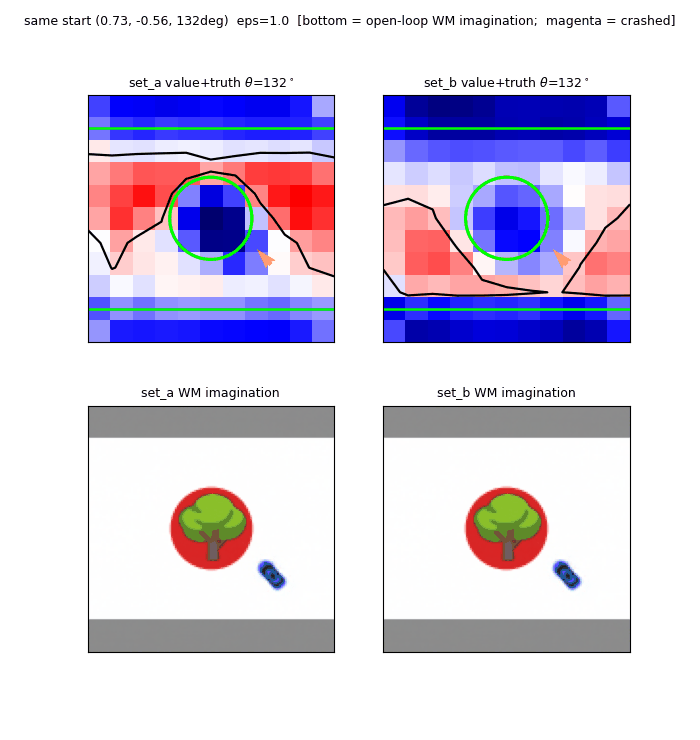

In [11]:
# comparison videos. objective='failure_mode': doomed starts, cars crash into DIFFERENT sets
# (set_a -> sidewalk, set_b -> obstacle).  objective='avoid': both stay safe, steer apart.
save_comparison_videos(objective='failure_mode', n=8)

pool: 22
[0] start=(0.27,-0.66,82deg) set_a=upper_sw set_b=obstacle eps=1.0


  saved compare_0.gif
[1] start=(-0.94,-0.03,10deg) set_a=upper_sw set_b=obstacle eps=1.0


  saved compare_1.gif
[2] start=(0.61,0.02,134deg) set_a=upper_sw set_b=obstacle eps=1.0


  saved compare_2.gif
[3] start=(0.73,-0.56,132deg) set_a=upper_sw set_b=obstacle eps=1.0


  saved compare_3.gif
[4] start=(0.52,-0.29,101deg) set_a=upper_sw set_b=obstacle eps=1.0


  saved compare_4.gif
[5] start=(-0.85,-0.35,34deg) set_a=upper_sw set_b=obstacle eps=1.0


  saved compare_5.gif
[6] start=(0.50,-0.63,107deg) set_a=upper_sw set_b=obstacle eps=1.0


  saved compare_6.gif
[7] start=(-0.69,0.11,23deg) set_a=upper_sw set_b=obstacle eps=1.0


  saved compare_7.gif
done -> visualizations/comparisons_failmode
